In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
class OISSpreadSimulator:
    """
    Simulateur de Bid-Ask Spread pour dérivés de taux
    utilisant un modèle CIR + Jump Diffusion.
    """

    def __init__(self, tenors, kappa=3.0, theta=1.0, sigma=0.5, lambda_jump=5.0, jump_mean=0.5):
        # Liste des maturités en années
        self.tenors = tenors
        self.kappa = kappa             # Vitesse de retour à la moyenne
        # Multiplicateur moyen de long terme (baseline)
        self.theta = theta
        self.sigma = sigma             # Volatilité du multiplicateur
        self.lambda_jump = lambda_jump  # Fréquence moyenne des chocs de liquidité par an
        # Taille moyenne du saut (distribution exponentielle)
        self.jump_mean = jump_mean

    def _baseline_spread(self, tenor):
        """
        Définit la structure par terme de la liquidité en conditions normales.
        Formule : 0.25 bps (overnight) + facteur pénalisant la maturité.
        """
        return 0.25 + 0.5 * np.sqrt(tenor)

    def simulate_multiplier(self, days=252, dt=1/252):
        """
        Simule la dynamique stochastique du multiplicateur de spread X_t.
        """
        X = np.zeros(days)
        X[0] = self.theta  # Initialisation à l'état neutre

        for t in range(1, days):
            # Diffusion 
            dW = np.random.normal(0, np.sqrt(dt))

            # Processus de Poisson
            is_jump = np.random.poisson(self.lambda_jump * dt)
            jump_size = np.random.exponential(
                self.jump_mean) if is_jump > 0 else 0

            # Schéma d'Euler pour le CIR
            drift = self.kappa * (self.theta - X[t-1]) * dt
            diffusion = self.sigma * np.sqrt(max(X[t-1], 0)) * dW

            X[t] = max(X[t-1] + drift + diffusion + jump_size, 0.01)

        return X

    def generate_surface(self, days=252):
        """
        Génère l'historique des spreads (en bps) pour chaque maturité.
        """
        X_t = self.simulate_multiplier(days)
        spread_history = {}

        for tenor in self.tenors:
            base_spread = self._baseline_spread(tenor)
            # Le spread final est le spread de base multiplié par la dynamique stochastique
            spread_history[f"{tenor}Y"] = base_spread * X_t

        dates = pd.date_range(start="2025-01-01", periods=days, freq='B')
        df_spreads = pd.DataFrame(spread_history, index=dates)

        return df_spreads

Statistiques des spreads simulés (en bps) :
           1Y      5Y     10Y     15Y     30Y
count  252.00  252.00  252.00  252.00  252.00
mean     1.02    1.87    2.50    2.99    4.08
std      0.19    0.34    0.46    0.55    0.75
min      0.65    1.19    1.59    1.90    2.60
25%      0.86    1.56    2.09    2.49    3.41
50%      1.05    1.92    2.57    3.07    4.20
75%      1.14    2.08    2.78    3.32    4.54
max      1.45    2.65    3.54    4.23    5.78


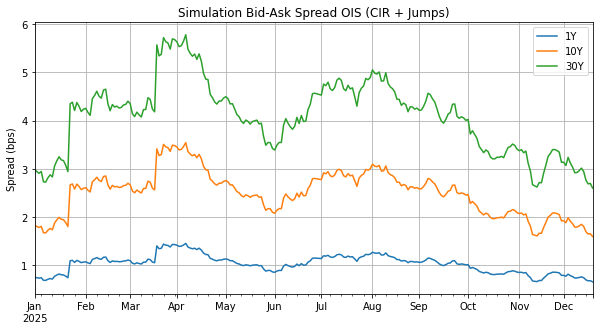

Résumé des divergences (en bps) entre Source A et Source B :
           1Y      5Y     10Y     15Y     30Y
count  252.00  252.00  252.00  252.00  252.00
mean     0.06    0.12    0.13    0.17    0.25
std      0.23    0.37    0.26    0.37    0.62
min      0.00    0.00    0.00    0.00    0.00
25%      0.02    0.03    0.04    0.05    0.06
50%      0.03    0.07    0.09    0.10    0.13
75%      0.06    0.12    0.15    0.17    0.25
max      3.52    4.03    2.52    3.23    5.56


In [ ]:
tenors_ois = [1, 5, 10, 15, 30]
simulator = OISSpreadSimulator(tenors=tenors_ois)

# 2. Générer 1 an de données quotidiennes
df_simulated_spreads = simulator.generate_surface(days=252)

# 3. Bid / Ask théoriques
mid_yield = 3.00
# Division par 100 pour passer de bps en %
df_ask = mid_yield + (df_simulated_spreads / 100 / 2)
df_bid = mid_yield - (df_simulated_spreads / 100 / 2)

print("Statistiques des spreads simulés (en bps) :")
print(df_simulated_spreads.describe().round(2))

df_simulated_spreads[['1Y', '10Y', '30Y']].plot(
    title="Bid-Ask Spread OIS",
    figsize=(10, 5),
    ylabel="Spread (bps)"
)
plt.grid(True)
plt.show()

def generate_source_B(df_source_A, noise_std=0.05, stale_prob=0.05, outlier_prob=0.01):
    """
    Une Source B perturbée.

    :param df_source_A: Le DataFrame contenant les trajectoires de la Source A.
    :param noise_std: Ecart-type du bruit microstructurel (0.05 = 5% de bruit).
    :param stale_prob: Probabilité qu'un prix ne soit pas mis à jour d'un jour à l'autre.
    :param outlier_prob: Probabilité d'une valeur aberrante (Fat finger).
    """
    # 1. Bruit Microstructurel Source_B = Source_A * (1 + epsilon) avec epsilon ~ N(0, noise_std^2)
    epsilon = np.random.normal(0, noise_std, size=df_source_A.shape)
    df_source_B = df_source_A * (1 + epsilon)

    B_values = df_source_B.values

    for col_idx in range(B_values.shape[1]):
        for t in range(1, B_values.shape[0]):

            # 2. Stale Quotes
            # Sur les maturités illiquides, la probabilité de prix figé est plus forte
            current_stale_prob = stale_prob * (1 + col_idx * 0.5)

            if np.random.rand() < current_stale_prob:
                B_values[t, col_idx] = B_values[t-1, col_idx]
                continue  #

            # 3. Outliers 
            if np.random.rand() < outlier_prob:
                # Un choc aléatoire entre +2 et +5 bps ou -2 et -5 bps
                direction = np.random.choice([-1, 1])
                magnitude = np.random.uniform(2.0, 5.0)
                B_values[t, col_idx] += (direction * magnitude)

    # floor : 0.01
    B_values = np.maximum(B_values, 0.01)

    return pd.DataFrame(B_values, index=df_source_A.index, columns=df_source_A.columns)

# ===========
# Application
# ===========

df_source_A = df_simulated_spreads
df_source_B = generate_source_B(df_source_A)

# Calcul du décalage entre les deux sources pour l'analyse IPV
df_divergence = np.abs(df_source_A - df_source_B)

print("Résumé des divergences (en bps) entre Source A et Source B :")
print(df_divergence.describe().round(2))
